In [2]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
from cmapPy.pandasGEXpress.parse import parse
import cmapPy.pandasGEXpress.subset_gctoo as sg

import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [3]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [4]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

## Select the gene signatures ids of compounds of interest

#### *1. Select all gene signature info with MCF7*

In [5]:
# read the gene signature info
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
sig_info.set_index("sig_id", inplace=True)

In [7]:
# select only the gene signature ids with MCF7
MCF7_sig_info = sig_info[sig_info['cell_id'] == 'MCF7']
MCF7_sig_info.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A12,BRD-K76908866,CP-724714,MCF7,0.04 um,24 h,LJP005_MCF7_24H_X1_B17:A12|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A13,BRD-K85606544,neratinib,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A13|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A14,BRD-K85606544,neratinib,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A14|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A15,BRD-K85606544,neratinib,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A15|LJP005_MCF7_24H_X2_...


In [8]:
# total number of gene signatures
len(MCF7_sig_info)

12737

#### *2. From these gene signatures, select only those with very high transcriptional responses (distil_ss > 10)*

##### a. Add the signature metrics to the sig_id info

In [99]:
# read the signature metrics of the gene signatures
file_path = "LINCS_dataset/all_data/GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt"
sig_metrics = pd.read_table(file_path, index_col=0)

# set the index as the signature id
sig_metrics.set_index('sig_id', inplace=True)

# get only the sig metrics for samples that were treated with MCF7 cell line
MCF7_distil_ss = sig_metrics.loc[MCF7_sig_info.index, 'distil_ss']
MCF7_distil_ss.head(10)

/home/katie_huang_student_uml_edu/.conda/envs/CMapPy_env/lib/python2.7/site-packages/ipykernel_launcher.py:3: FutureWarning: read_table is deprecated, use read_csv instead, passing sep='\t'.
  This is separate from the ipykernel package so we can avoid doing imports until


sig_id
LJP005_MCF7_24H:A07    4.43478
LJP005_MCF7_24H:A08    3.74541
LJP005_MCF7_24H:A09    4.36937
LJP005_MCF7_24H:A10    2.89872
LJP005_MCF7_24H:A11    4.40471
LJP005_MCF7_24H:A12    2.99718
LJP005_MCF7_24H:A13    4.16410
LJP005_MCF7_24H:A14    4.13239
LJP005_MCF7_24H:A15    4.31515
LJP005_MCF7_24H:A16    2.95443
Name: distil_ss, dtype: float64

In [94]:
# add the distil_ss scores to the sig_info for MCF7
MCF7_trt_cps = pd.concat([MCF7_sig_info, MCF7_distil_ss], axis=1)
MCF7_trt_cps.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,distil_ss
sig_id,,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...,4.43478
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...,3.74541
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...,4.36937
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...,2.89872
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...,4.40471
LJP005_MCF7_24H:A12,BRD-K76908866,CP-724714,MCF7,0.04 um,24 h,LJP005_MCF7_24H_X1_B17:A12|LJP005_MCF7_24H_X2_...,2.99718
LJP005_MCF7_24H:A13,BRD-K85606544,neratinib,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A13|LJP005_MCF7_24H_X2_...,4.16410
LJP005_MCF7_24H:A14,BRD-K85606544,neratinib,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A14|LJP005_MCF7_24H_X2_...,4.13239
LJP005_MCF7_24H:A15,BRD-K85606544,neratinib,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A15|LJP005_MCF7_24H_X2_...,4.31515


##### b. Sort the samples by distil_ss scores

It was decided to select samples to compare by using distil_ss scores, which represents the magnitude of differential expression of the landmark genes when comparing the average drug treatment to the DMSO treatment.

This was taken from https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4965635/.

In [64]:
# sort samples by distil_ss scores
MCF7_trt_cps.sort_values('distil_ss', ascending=False, inplace=True)
MCF7_trt_cps.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,distil_ss
sig_id,,,,,,,
REP.A013_MCF7_24H:F17,BRD-K39252998,atipamezole,MCF7,0.12 um,24 h,REP.A013_MCF7_24H_X1_B24:F17,19.6371
LJP005_MCF7_3H:D12,BRD-K63923597,barasertib-HQPA,MCF7,0.04 um,3 h,LJP005_MCF7_3H_X2_B17:D12,19.6262
REP.A011_MCF7_24H:J05,BRD-K06335600,tizanidine,MCF7,0.12 um,24 h,REP.A011_MCF7_24H_X1_B24:J05|REP.A011_MCF7_24H...,19.0095
REP.A011_MCF7_24H:A24,BRD-K04112579,nepafenac,MCF7,0.04 um,24 h,REP.A011_MCF7_24H_X1_B24:A24|REP.A011_MCF7_24H...,18.1413
REP.A004_MCF7_24H:H14,BRD-K22848513,bardoxolone-methyl,MCF7,3.33 um,24 h,REP.A004_MCF7_24H_X1_B27:H14|REP.A004_MCF7_24H...,17.6782
REP.A004_MCF7_24H:H13,BRD-K22848513,bardoxolone-methyl,MCF7,10.0 um,24 h,REP.A004_MCF7_24H_X1_B27:H13|REP.A004_MCF7_24H...,17.4624
REP.A014_MCF7_24H:J01,BRD-K60997853,PHA-848125,MCF7,10.0 um,24 h,REP.A014_MCF7_24H_X1_B23:J01|REP.A014_MCF7_24H...,17.3304
REP.A011_MCF7_24H:E01,BRD-K05104363,PD-184352,MCF7,10.0 um,24 h,REP.A011_MCF7_24H_X1_B24:E01|REP.A011_MCF7_24H...,17.2963
REP.A002_MCF7_24H:K02,BRD-K17500877,bropirimine,MCF7,3.33 um,24 h,REP.A002_MCF7_24H_X1_B27:K02|REP.A002_MCF7_24H...,17.2601


In [65]:
# select only the samples with a distil_ss sample above 10
high_distil_ss = MCF7_trt_cps['distil_ss'] > 10
top_MCF7_samples = MCF7_trt_cps.loc[high_distil_ss]
len(top_MCF7_samples)

923

##### c. For each unique compound, select the sample with the highest distil_ss score

In [67]:
# create a list to store the sig ids of all the samples with that highest distil_ss scores
highest_distil_ss_sig_ids = []

# group the data by the name of the compound
by_cps = top_MCF7_samples.groupby("pert_iname")

# store the compound names and their sig ids in a dictionary
cp2samples = by_cps.groups

# look at each compound names and the sig ids for that compound
for cp_name, sig_ids in cp2samples.items():
    # obtain the dataframe with that data
    data = top_MCF7_samples.loc[sig_ids]
    
    # sort the data by highest distil_ss score
    distil_ss_sorted = data.sort_values('distil_ss', ascending=False)

    # obtain the data for the sample with the highest distil_ss scores
    highest_distil_ss = distil_ss_sorted.iloc[0]
    
    # add the sig id to the running list
    highest_distil_ss_sig_ids.append(highest_distil_ss.name)

# create a dataframe containing the distill_ss score for each unique compound whose distill_ss > 10
samples2compare = top_MCF7_samples.loc[highest_distil_ss_sig_ids]
samples2compare.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,distil_ss
sig_id,,,,,,,
REP.A022_MCF7_24H:I02,BRD-K71281111,SNX-2112,MCF7,3.33 um,24 h,REP.A022_MCF7_24H_X1_B23:I02|REP.A022_MCF7_24H...,10.4523
REP.A008_MCF7_24H:A09,BRD-A68009927,daunorubicin,MCF7,1.11 um,24 h,REP.A008_MCF7_24H_X1_B24:A09|REP.A008_MCF7_24H...,15.5083
REP.A011_MCF7_24H:J05,BRD-K06335600,tizanidine,MCF7,0.12 um,24 h,REP.A011_MCF7_24H_X1_B24:J05|REP.A011_MCF7_24H...,19.0095
REP.A025_MCF7_24H:P03,BRD-K79131256,albendazole,MCF7,1.11 um,24 h,REP.A025_MCF7_24H_X1_B23:P03|REP.A025_MCF7_24H...,11.0716
REP.A027_MCF7_24H:E15,BRD-K94436377,diosmin,MCF7,1.11 um,24 h,REP.A027_MCF7_24H_X1_B25:E15|REP.A027_MCF7_24H...,13.2514
LJP009_MCF7_24H:A03,BRD-K81418486,vorinostat,MCF7,10.0 um,24 h,LJP009_MCF7_24H_X1_B20:A03|LJP009_MCF7_24H_X2_...,10.0483
REP.A018_MCF7_24H:C07,BRD-K62627508,idasanutlin,MCF7,10.0 um,24 h,REP.A018_MCF7_24H_X1_B24:C07|REP.A018_MCF7_24H...,14.5830
REP.A023_MCF7_24H:P16,BRD-K73088654,floxuridine,MCF7,0.37 um,24 h,REP.A023_MCF7_24H_X1_B23:P16|REP.A023_MCF7_24H...,12.7571
REP.A008_MCF7_24H:A13,BRD-K35960502,niclosamide,MCF7,10.0 um,24 h,REP.A008_MCF7_24H_X1_B24:A13|REP.A008_MCF7_24H...,13.4855


In [69]:
# get the number of compounds to compare
len(samples2compare)

129

## Map the drugs to the diseases

The diseases related to each drug was taken from the Broad Institute:
https://repo-hub.broadinstitute.org/repurposing#download-data

In [70]:
# import the disease information for each drug
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/repurposing_drugs_20200324.txt'
disease_info = pd.read_csv(file_path, sep="\t", dtype=str, skiprows=9)

# set the index as the name of the compound
disease_info.set_index('pert_iname', inplace=True)
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
(R)-(-)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A,NaN,NaN
(R)-baclofen,Phase 3,benzodiazepine receptor agonist,GABBR1|GABBR2,NaN,NaN
(S)-(+)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4B|PDE4D,NaN,NaN
"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN


In [71]:
# remove pert_inames where there is no indication (NaN)
disease_info = disease_info[disease_info['indication'].notna()]
disease_info.head(10)

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
abacavir,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abamectin,Launched,benzodiazepine receptor agonist,GABBR1|GABBR2,infectious disease,gastrointestinal parasites
abemaciclib,Launched,CDK inhibitor,CDK4|CDK6,oncology,breast cancer
abiraterone,Launched,androgen biosynthesis inhibitor,CYP11B1|CYP17A1,oncology,prostate cancer
abiraterone-acetate,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acalabrutinib,Launched,Bruton's tyrosine kinase (BTK) inhibitor,BTK,hematologic malignancy,mantle cell lymphoma (MCL)
acamprosate,Launched,glutamate receptor antagonist,GABRA1|GABRA2|GABRA3|GABRA4|GABRA5|GABRA6|GABR...,neurology/psychiatry,abstinence from alcohol
acarbose,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [72]:
# obtain the pert_info data
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_pert_info.txt'
pert_info = pd.read_csv(file_path, sep="\t", dtype=str)

# set the index of the dataframe as the pert_iname
pert_info.set_index('pert_iname', inplace=True)
pert_info.head(10)

,pert_id,canonical_smiles,inchi_key,pert_type
pert_iname,,,,
10-DEBC,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,trt_cp
phorbol-myristate-acetate,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,trt_cp
"16,16-dimethylprostaglandin-e2",BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,trt_cp
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp
2-iminobiotin,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,trt_cp
2-methoxyestradiol,BRD-K44408410,COc1cc2[C@H]3CC[C@]4(C)[C@@H](O)CC[C@H]4[C@@H]...,CQOQDQWUFQDJMK-SSTWWWIQSA-N,trt_cp
"2',5'-dideoxyadenosine",BRD-A20131130,CC1OC(CC1O)n1cnc2c(N)ncnc12,FFHPXOJTVQDVMO-UHFFFAOYSA-N,trt_cp
3-amino-benzamide,BRD-K08703257,NC(=O)c1cccc(N)c1,GSCPDZHWVNUUFI-UHFFFAOYSA-N,trt_cp
3-deazaadenosine,BRD-A79431551,Nc1nccc2n(cnc12)[C@@H]1O[C@H](CO)C(O)C1O,DBZQFUNLCALWDY-JXACCQRMSA-N,trt_cp


In [73]:
# select only the drugs associated with a disease
drug_to_disease = pert_info.merge(disease_info, how='inner', on='pert_iname')
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp,Launched,progesterone receptor agonist,AR|ESR1|ESR2|NR1H4|NR1I2|NR3C1|PGR,obstetrics/gynecology,spontaneous preterm birth
5-aminolevulinic-acid,BRD-K57631554,NCC(=O)CCC(O)=O,ZGXJTSGNIOSYLO-UHFFFAOYSA-N,trt_cp,Launched,oxidizing agent,ALAD,oncology|dermatology,glioma|actinic keratosis (AK)
abacavir,BRD-A95032015,Nc1nc(NC2CC2)c2ncn(C3C[C@H](CO)C=C3)c2n1,MCGSCOLBFJQGHM-HNHGDDPOSA-N,trt_cp,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abiraterone-acetate,BRD-K16133773,CC(=O)O[C@H]1CC[C@]2(C)[C@@H]3CC[C@@]4(C)[C@@H...,UVIQSJCZCSLXRZ-HCWFNAMGSA-N,trt_cp,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acarbose,BRD-K01621533,C[C@@H]1O[C@H](O[C@@H]2[C@H](CO)O[C@H](O[C@@H]...,XUFXOAAUWZOOIT-PCKYEMPFSA-N,trt_cp,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [74]:
# calculate the total number of drugs associated with a disease
len(drug_to_disease)

884

In [75]:
# sort the drugs by their disease area and disease indication
drug_to_disease = drug_to_disease.sort_values(by=['disease_area', 'indication'])
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
acrivastine,BRD-K50163129,Cc1ccc(cc1)C(=C/CN1CCCC1)\c1cccc(\C=C\C(O)=O)n1,PWACSDKDOHSSQD-IUTFFREVSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
beclomethasone-dipropionate,BRD-A11319535,CCC(=O)OCC(=O)C1(OC(=O)CC)C(C)CC2C3CCC4=CC(=O)...,KUVIULQEHSCUHY-UHFFFAOYSA-N,trt_cp,Launched,glucocorticoid receptor agonist,GPR97|NR3C1,allergy,allergic rhinitis
ciclesonide,BRD-K35245662,CC(C)C(=O)OCC(=O)[C@@]12O[C@@H](O[C@@H]1C[C@H]...,LUKZNWIVRBCLON-GXOBDPJESA-N,trt_cp,Launched,glucocorticoid receptor agonist,NR3C1|SERPINA6,allergy,allergic rhinitis
clemizole,BRD-K04704168,Clc1ccc(Cn2c(CN3CCCC3)nc3ccccc23)cc1,CJXAEXPPLWQRFR-UHFFFAOYSA-N,trt_cp,Launched,HCV inhibitor,NaN,allergy,allergic rhinitis
diphenylpyraline,BRD-K22936972,CN1CCC(CC1)OC(c1ccccc1)c1ccccc1,OWQUZNMMYNAXSL-UHFFFAOYSA-N,trt_cp,Launched,dopamine reuptake inhibitor,HRH1|SLC6A3,allergy,allergic rhinitis


## Select drugs to compare based on these disease indications

#### *1. Show only the compounds that have high distil_ss scores with a drug indication*

In [76]:
# select all the samples with high distil_ss scores treated with MCF7 that have a disease associated with it
test_samples = samples2compare[samples2compare['pert_iname'].isin(drug_to_disease.index)]

# unique compound ids with associated diseases
unique_cp_ids = test_samples['pert_id'].unique()

In [77]:
unique_cp_ids

array(['BRD-A68009927', 'BRD-K06335600', 'BRD-K79131256', 'BRD-K94436377',
       'BRD-K81418486', 'BRD-K73088654', 'BRD-K35960502', 'BRD-K21361524',
       'BRD-K24616672', 'BRD-A45889380', 'BRD-K14619660', 'BRD-K05395900',
       'BRD-A30051119', 'BRD-K92984783', 'BRD-K75649340', 'BRD-A33084557',
       'BRD-A35108200', 'BRD-K13646352', 'BRD-K76674262', 'BRD-K15409150',
       'BRD-K39252998', 'BRD-K56844688', 'BRD-K78659596', 'BRD-A40787240',
       'BRD-K28307902', 'BRD-K50691590', 'BRD-K96550715', 'BRD-K19687926',
       'BRD-K92093830', 'BRD-K92213669', 'BRD-K17743125', 'BRD-K89561498',
       'BRD-K21680192', 'BRD-K72951360', 'BRD-K15179879', 'BRD-K61443650',
       'BRD-A94756469', 'BRD-K74717603', 'BRD-K78431006', 'BRD-K04112579',
       'BRD-K10961822', 'BRD-K57041787', 'BRD-A10039652', 'BRD-K61397605',
       'BRD-A66419424'], dtype=object)

In [78]:
# number of unique compounds with associated diseases
len(unique_cp_ids)

45

#### *2. Categorize the pert_ids by their indication*

In [79]:
# list the indication of these compounds
drug2indications = drug_to_disease[['pert_id', 'indication']][drug_to_disease['pert_id'].isin(unique_cp_ids)]
drug2indications

,pert_id,indication
pert_iname,,
digoxin,BRD-A94756469,congestive heart failure|atrial fibrillation (AF)
diosmin,BRD-K94436377,chronic venous insufficiency (CVI)|edema|deep ...
linagliptin,BRD-K96550715,diabetes mellitus
altrenogest,BRD-K14619660,estrus
lomitapide,BRD-K92213669,hypercholesterolemia
dexamethasone,BRD-A35108200,hypercalcemia|rheumatoid arthritis|psoriatic a...
midostaurin,BRD-K13646352,acute myeloid leukemia (AML)
daunorubicin,BRD-A68009927,acute myeloid leukemia (AML)|acute lymphoblast...
tioguanine,BRD-K75649340,acute myeloid leukemia (AML)|acute lymphoblast...


In [80]:
print(drug2indications.loc['bortezomib', 'indication'])

multiple myeloma|mantle cell lymphoma (MCL)


## Create pairs of drugs to compare that share or do not share indications

#### *1. Create pairs of drug ids to compare group by whether they share an indication (are similar)*

In [81]:
# create an empty dictionary
pairs2compare = {
    'similar drugs': [],
    'different drugs': []
}

# set the pert_id as the index
id2indications = drug2indications.set_index('pert_id')

# obtain all the ids of all the compounds
all_cps = id2indications.index

# look through the indices of the list of unique compounds up until the 2nd last index
for idx, pert_id in enumerate(all_cps):
    # store all the indications of this compound
    indications_str = id2indications.loc[pert_id, 'indication']
    # store all the indications for this compound as set
    indications_set = set(indications_str.split('|'))
    # create a subset of the dataframe containing the remaining compounds
    other_ids = id2indications.iloc[idx+1:]
    # look through each of the remaining compounds
    for i, cp in other_ids.iterrows():
        # store the indications of each compound as a string
        other_cp_indications_str = cp['indication']
        # store the indications of each compound as a set
        other_cp_indications_set = set(other_cp_indications_str.split('|'))
        # determine the same indications across both compounds
        common_indications = indications_set.intersection(other_cp_indications_set)
        # add the pert_ids of the two drugs to the a list 
        cps_pair = [pert_id, i]
        
        # check if there are samples that have been treated with this compound
        cp_ids_in_data = samples2compare['pert_id'].isin(cps_pair)
        # get the data associated with these compounds
        cp_data = samples2compare[cp_ids_in_data]
        
        # if they share indications,
        if common_indications:
            # add this data to the list of similar drugs in the dictionary
            pairs2compare['similar drugs'].append(cp_data)
        # otherwise, they are different drugs
        else:
            # add this data to the list of different drugs in the dictionary
            pairs2compare['different drugs'].append(cp_data)

# check that you have unique pairs of compounds to compare to each other
pairs2compare['similar drugs'][0]

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,distil_ss
sig_id,,,,,,,
REP.A027_MCF7_24H:E15,BRD-K94436377,diosmin,MCF7,1.11 um,24 h,REP.A027_MCF7_24H_X1_B25:E15|REP.A027_MCF7_24H...,13.2514
REP.A015_MCF7_24H:F17,BRD-K57041787,dabigatran-etexilate,MCF7,0.12 um,24 h,REP.A015_MCF7_24H_X2_B23:F17|REP.A015_MCF7_24H...,13.0830


In [82]:
# find the total number of pairs of similar drugs
len(pairs2compare['similar drugs'])

36

In [83]:
# find the total number of pairs of different drugs
len(pairs2compare['different drugs'])

954

#### *2. Select the gene signatures for each pair*

In [84]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# select only the landmark gene of drug compounds of interest
gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)

# get the metadata for one of the pairs
pair_metadata = pairs2compare['similar drugs'][0]

# get the sig ids for one of the pairs to compare
pair_ids = list(pair_metadata.index.values)

# get the signatures of only those two compounds
pair_gene_sigs = sg.subset_gctoo(gene_sigs, cid=pair_ids)

# create a new GCTOO object with all the metadata for each sample
sig_info = GCToo.GCToo(data_df=pair_gene_sigs.data_df.copy(), 
                       row_metadata_df=pair_gene_sigs.row_metadata_df.copy(), 
                       col_metadata_df=pair_metadata.copy(), 
                       make_multiindex=True)

sig_info.multi_index_df[:5]

pert_id,BRD-K57041787,BRD-K94436377
pert_iname,dabigatran-etexilate,diosmin
cell_id,MCF7,MCF7
pert_idose,0.12 um,1.11 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X2_B23:F17|REP.A015_MCF7_24H_X3_B23:F17,REP.A027_MCF7_24H_X1_B25:E15|REP.A027_MCF7_24H_X2_B25:E15|REP.A027_MCF7_24H_X3_B25:E15
distil_ss,13.0830,13.2514
cid,REP.A015_MCF7_24H:F17,REP.A027_MCF7_24H:E15
rid,,
0,2.90605,0.213195
1,6.70555,-0.048065


In [85]:
# creating a function to create a dataframe containing the gene signatures of the pert_ids of interest
def select_gene_sigs(lm_gene_id, gene_sigs, pair_metadata):
    # get the sig ids for one of the pairs to compare
    pair_ids = list(pair_metadata.index.values)

    # get the signatures of only those two compounds
    pair_gene_sigs = sg.subset_gctoo(gene_sigs, cid=pair_ids)

    # create a new GCTOO object with all the metadata for each sample
    sig_info = GCToo.GCToo(data_df=pair_gene_sigs.data_df.copy(), 
                           row_metadata_df=pair_gene_sigs.row_metadata_df.copy(), 
                           col_metadata_df=pair_metadata.copy(), 
                           make_multiindex=True)
    return sig_info

In [86]:
# check that the function is working using one pair of similar drugs
test_pair = pairs2compare['similar drugs'][0]
sig_info = select_gene_sigs(lm_gene_id, gene_sigs, test_pair)
sig_info.multi_index_df[:5]

pert_id,BRD-K57041787,BRD-K94436377
pert_iname,dabigatran-etexilate,diosmin
cell_id,MCF7,MCF7
pert_idose,0.12 um,1.11 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X2_B23:F17|REP.A015_MCF7_24H_X3_B23:F17,REP.A027_MCF7_24H_X1_B25:E15|REP.A027_MCF7_24H_X2_B25:E15|REP.A027_MCF7_24H_X3_B25:E15
distil_ss,13.0830,13.2514
cid,REP.A015_MCF7_24H:F17,REP.A027_MCF7_24H:E15
rid,,
0,2.90605,0.213195
1,6.70555,-0.048065


In [87]:
## automate the process of selecting the gene signatures for each pair
# create an empty dictionary to store the gene signatures of each pair
pairs_sig_info = {
    'similar drugs': [],
    'different drugs': []
}

# look at each group drugs (similar vs different)
for group in pairs2compare:
    # get all the pairs in group
    pairs_in_group = pairs2compare[group]
    # look at each pair of compounds in each group
    for pair_of_cps in pairs_in_group:
        # select the sig_info for these compounds
        sig_info = select_gene_sigs(lm_gene_id, gene_sigs, pair_of_cps)
        # add this sig info to the correct group of the new dictionary
        pairs_sig_info[group].append(sig_info)

# check that automating process was correct
test_pair = pairs_sig_info['similar drugs'][0]
test_pair.multi_index_df[:5]

pert_id,BRD-K57041787,BRD-K94436377
pert_iname,dabigatran-etexilate,diosmin
cell_id,MCF7,MCF7
pert_idose,0.12 um,1.11 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X2_B23:F17|REP.A015_MCF7_24H_X3_B23:F17,REP.A027_MCF7_24H_X1_B25:E15|REP.A027_MCF7_24H_X2_B25:E15|REP.A027_MCF7_24H_X3_B25:E15
distil_ss,13.0830,13.2514
cid,REP.A015_MCF7_24H:F17,REP.A027_MCF7_24H:E15
rid,,
0,2.90605,0.213195
1,6.70555,-0.048065


## Perform Spearman correlations for all pairs of drugs

In [88]:
# function to create a scatter plot for each drug dosage comparing 2 drug compounds
def spearman_correlation(pair_of_sigs):
    # make a scatterplot 
    #sns.scatterplot(
        #x = pair_of_sigs.data_df.iloc[:, 0],
        #y = pair_of_sigs.data_df.iloc[:, 1]
    #)
    # label x-axis of the scatterplot with the compound name
    #plt.xlabel(pair_of_sigs.col_metadata_df.iloc[0].pert_iname)
    # label y-axis of the scatterplot with the compound name
    #plt.ylabel(pair_of_sigs.col_metadata_df.iloc[1].pert_iname)
    # label title with dose being compared at
    #plt.title(pair_of_sigs.col_metadata_df.iloc[0].pert_idose)
    #plt.show()

    # perform a spearman correlation
    spearman_corr, p_value = stats.spearmanr(pair_of_sigs.data_df.iloc[:, 0], pair_of_sigs.data_df.iloc [:,1])
    #print('Spearman Correlation:', spearman_corr, 'p value:', p_value)
    return spearman_corr, p_value

#### *1. Compare all pairs of drugs that share the same indication (are similar)*

In [89]:
# create a dictionary to store the spearman correlations and their respective p values
spearman_corrs = {
    'spearman correlation': [],
    'p value': [],
    'share an indication': []
}

# store all the pairs of drugs that share an indication in a list
similar_pairs = pairs_sig_info['similar drugs']

# for each pair of drugs that share an indication,
for pair in similar_pairs:
    # make a scatter plot and perform a spearman correlation and store the correlation and p values
    corr, p = spearman_correlation(pair)
    
    # add the correlation to the running list of all spearman correlations
    spearman_corrs['spearman correlation'].append(corr)
    
    # add the p value to the running list of all p values
    spearman_corrs['p value'].append(p)
    
    # indicate they share an indication
    spearman_corrs['share an indication'].append('share an indication')

#### *2. Compare pairs of drugs that do not share an indication (are different)*

In [90]:
# store all the pairs of drugs that share an indication in a list
diff_pairs = pairs_sig_info['different drugs']

# for each pair of drugs that share an indication,
for pair in diff_pairs:
    # make a scatter plot and perform a spearman correlation and store the correlation and p values
    corr, p = spearman_correlation(pair)
    
    # add the correlation to the running list of all spearman correlations
    spearman_corrs['spearman correlation'].append(corr)
    
    # add the p value to the running list of all p values
    spearman_corrs['p value'].append(p)
    
    # indicate that the two drugs do not share an indication
    spearman_corrs['share an indication'].append('do not share an indication')

In [91]:
# convert the dictionary into a dataframe
spearman_corrs_df = pd.DataFrame(spearman_corrs)
spearman_corrs_df.head(10)

,p value,share an indication,spearman correlation
0,4.910555e-07,share an indication,0.160002
1,2.748131e-04,share an indication,-0.116084
2,1.310416e-28,share an indication,0.344347
3,2.400065e-01,share an indication,0.037606
4,1.838192e-41,share an indication,0.412478
5,9.617408e-11,share an indication,0.205038
6,7.979707e-30,share an indication,0.351537
7,1.131651e-97,share an indication,0.602477
8,7.620283e-96,share an indication,0.597887
9,1.277048e-12,share an indication,0.224319


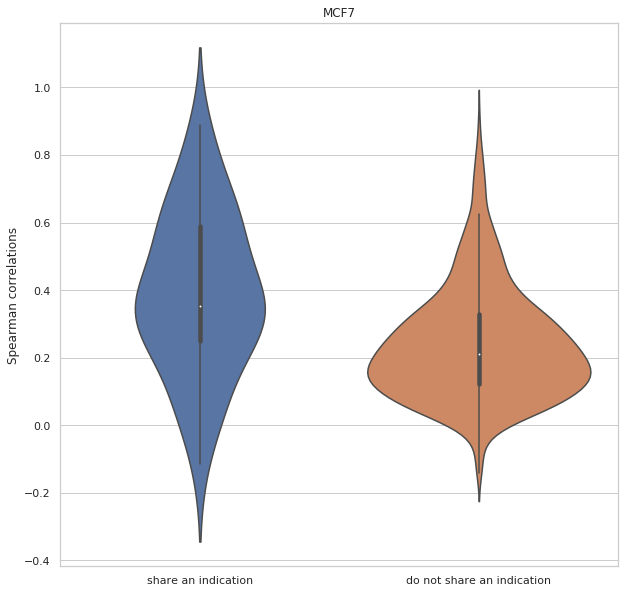

In [92]:
# create a new figure for the histograms with specified sizes
plt.figure(figsize=(10,10))

# set a grid on the histograms
sns.set(style='whitegrid')

# create a histogram of all spearman correlations for pairs of similar drugs
sns.violinplot(data=spearman_corrs, x='share an indication', y='spearman correlation', inner='box', common_norm=False)

# Customize the plot
plt.title("MCF7")
plt.ylabel("Spearman correlations")

# Show the plot
plt.show()